# Step 1: Environment Setup & Data Loading
Load the dataset generated by `data_collector.py` and strictly validate the project path.

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from typing import cast

# 1. Configurable project root via environment variable, defaulting to current working directory
PROJECT_ROOT = os.environ.get('AI_PIPELINE_ROOT', os.getcwd())
dataset_path = os.path.join(PROJECT_ROOT, 'datasets', 'blink_dataset.csv')

# 2. Explicit existence check with a clear error
if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"\n[CRITICAL ERROR] Dataset CSV is missing!\n"
        f"Looked in: {dataset_path}\n"
        f"Fix: Set the 'AI_PIPELINE_ROOT' environment variable to your project directory, "
        f"or ensure your Jupyter server is running inside the 'ai_pipeline' folder."
    )

print(f"Loading raw dataset from: {dataset_path}")

# 3. Load data with type hinting fixes using typing.cast
raw_data = pd.read_csv(dataset_path)  # type: ignore
df = cast(pd.DataFrame, raw_data)

print("\n--- RAW DATA COUNTS ---")
print(df['Label'].value_counts().sort_index())

Loading raw dataset from: C:\Users\ahmed\Documents\grad_project\ai_pipeline\gaze_intent\datasets\blink_dataset.csv

--- RAW DATA COUNTS ---
Label
0    7058
1    7500
2    6678
3    6512
Name: count, dtype: int64


# Step 2: Transition Frame Cleaning
In live video, the frames where an eye is "half-closed" pollute the dataset. We use a strict EAR threshold to identify these ambiguous transition frames and safely reassign them to the Neutral class.

In [2]:
# Automatically calculate the user's specific threshold based on their dataset
avg_open_ear = df[df['Label'] == 0][['Left_EAR', 'Right_EAR']].median().mean()
avg_closed_ear = df[df['Label'] == 3][['Left_EAR', 'Right_EAR']].median().mean()

# Set the threshold exactly halfway between their natural open and closed states
threshold = (avg_open_ear + avg_closed_ear) / 2.0

print(f"Dynamically calculated user threshold: {threshold:.3f}")

# --- THE CLEANING RULES ---
# Rule for Left Wink (1): Left eye MUST be closed, Right eye MUST be open
condition_left_wink = (df['Label'] == 1) & ((df['Left_EAR'] > threshold) | (df['Right_EAR'] < threshold))

# Rule for Right Wink (2): Right eye MUST be closed, Left eye MUST be open
condition_right_wink = (df['Label'] == 2) & ((df['Right_EAR'] > threshold) | (df['Left_EAR'] < threshold))

# Rule for Sustained Closure (3): BOTH eyes MUST be closed
condition_closure = (df['Label'] == 3) & ((df['Left_EAR'] > threshold) | (df['Right_EAR'] > threshold))

# Identify all dirty transition frames
dirty_frames = condition_left_wink | condition_right_wink | condition_closure

# Reassign the dirty frames back to Neutral (0)
df.loc[dirty_frames, 'Label'] = 0

print(f"Total transition frames safely moved to Neutral: {dirty_frames.sum()}")
print("\n--- CLEAN DATA COUNTS ---")
print(df['Label'].value_counts().sort_index())

Total transition frames safely moved to Neutral: 16836

--- CLEAN DATA COUNTS ---
Label
0    23894
1      903
2      990
3     1961
Name: count, dtype: int64


# Step 3: Feature Selection & Model Training
Isolate the specific temporal features and train a lightweight Random Forest model capped at a depth of 10 to ensure real-time C++ performance.

In [3]:
# Define Features (X) and Labels (y) explicitly to avoid data leakage
X = df[['Left_EAR', 'Left_Min_10f', 'Left_Var_10f',
        'Right_EAR', 'Right_Min_10f', 'Right_Var_10f',
        'BoundingBox_Area']]
y = df['Label']

# Split the data: 80% for training, 20% for testing the accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Random Forest Classifier...")
# max_depth=10 prevents overfitting and keeps the model execution blazing fast
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
print("Training Complete!")

Training Random Forest Classifier...
Training Complete!


# Step 4: Model Evaluation
Verify that the model isn't just defaulting to "Neutral" by checking its precision and recall across all 4 specific states using a confusion matrix.

--- MODEL ACCURACY: 99.06% ---

              precision    recall  f1-score   support

     Neutral       0.99      1.00      0.99      4779
   Left Wink       0.99      0.99      0.99       181
  Right Wink       0.97      0.95      0.96       198
     Closure       0.97      0.94      0.95       392

    accuracy                           0.99      5550
   macro avg       0.98      0.97      0.98      5550
weighted avg       0.99      0.99      0.99      5550



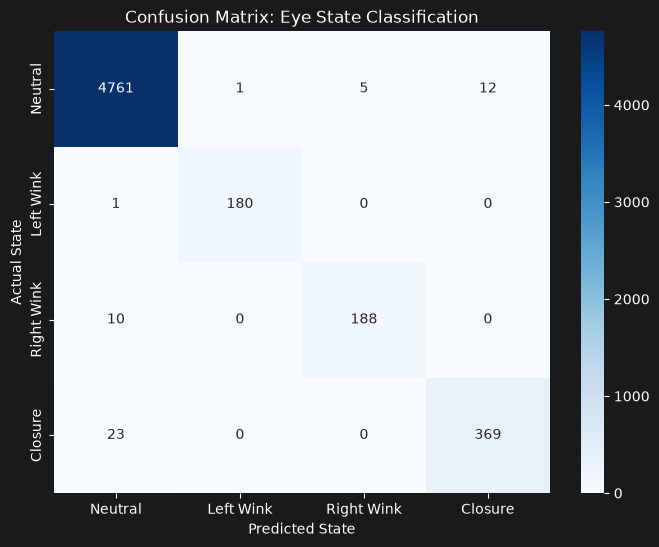

In [4]:
# Test the model
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"--- MODEL ACCURACY: {accuracy * 100:.2f}% ---\n")
print(classification_report(y_test, y_pred, target_names=['Neutral', 'Left Wink', 'Right Wink', 'Closure']))

# Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neutral', 'Left Wink', 'Right Wink', 'Closure'],
            yticklabels=['Neutral', 'Left Wink', 'Right Wink', 'Closure'])

plt.title('Confusion Matrix: Eye State Classification')
plt.ylabel('Actual State')
plt.xlabel('Predicted State')
plt.show()

# Step 5: Export for C++ Integration
Serialize the trained model into a `.pkl` file so the production `gaze_intent.py` module can load it instantly.

In [5]:
import os
import joblib

# Resolve relative to the same explicit project root
PROJECT_ROOT = os.environ.get('AI_PIPELINE_ROOT', os.getcwd())
model_output_path = os.path.join(PROJECT_ROOT, 'gesture_model.pkl')

# Save the compiled model so the C++ engine can use it
joblib.dump(clf, model_output_path)
print(f"Production Model successfully saved to:\n{model_output_path}")

Production Model successfully saved to:
C:\Users\ahmed\Documents\grad_project\ai_pipeline\gaze_intent\gesture_model.pkl
